<a href="https://colab.research.google.com/github/amit-devs/Amit_ML_Practicals/blob/main/ML_Extra_Practical/Extra_Practical_9_ML_CS23091.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Step 2: Load dataset

df = pd.read_csv('/content/drive/MyDrive/ML_DATASETS/WineQT.csv')  # change path if needed

# Display first 5 rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
# Step 3: Check data info

print(df.info())
print(df.describe())

# Drop unnecessary column (Id if present)
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Separate features (we don't use 'quality' for clustering)
X = df.drop(columns=['quality'])

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \

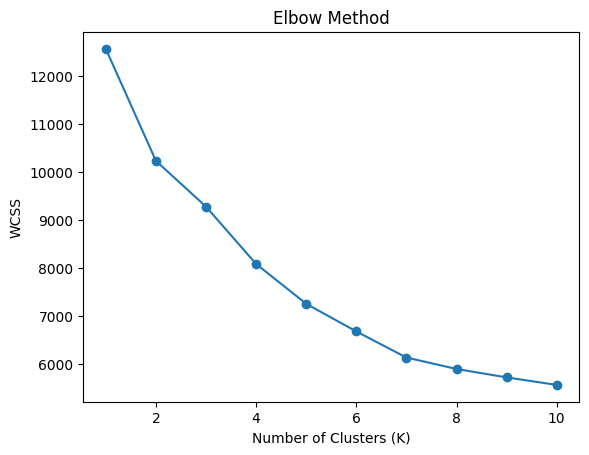

In [ ]:
# Step 4: Elbow Method

wcss = []  # within-cluster sum of squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# Step 5: Apply KMeans (change n_clusters based on elbow)

k = 3  # example
kmeans = KMeans(n_clusters=k, random_state=42)

y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = y_kmeans

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


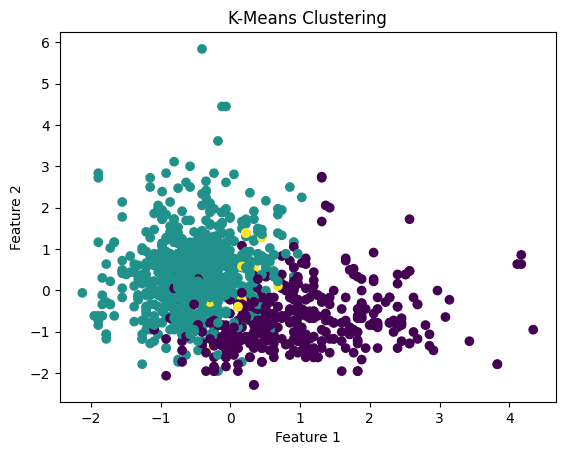

In [ ]:
# Step 6: Visualization using first 2 features

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
# Step 7: Analyze clusters

cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

         fixed acidity  volatile acidity  citric acid  residual sugar  \
Cluster                                                                 
0             9.962750          0.408988     0.461900        2.906750   
1             7.394061          0.598833     0.153881        2.338329   
2             8.484211          0.535263     0.556316        2.031579   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
Cluster                                                                   
0         0.086140            13.165000             38.180000  0.997741   
1         0.079854            16.962017             49.713398  0.996163   
2         0.373368            15.894737             64.000000  0.997088   

               pH  sulphates    alcohol   quality  
Cluster                                            
0        3.212025   0.723025  10.704917  5.947500  
1        3.372983   0.605304  10.323297  5.502762  
2        3.033684   1.279474   9.436842  5.421053 

In [ ]:
# Step 8: Evaluate clustering

score = silhouette_score(X_scaled, y_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.21811891686992646
